In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")


data_path = "/Users/bonsitukebeto/Library/CloudStorage/OneDrive-NorthwesternUniversity/Data/CAR_-_EP_Flow_Activity_Queue__Agent_Names"

folder = Path(data_path)
files = sorted(list(folder.glob("*.csv")) + list(folder.glob("*.xlsx")))

df_main = pd.DataFrame(columns=['Contact Session ID', 'EP Name', 'Flow Name', 'Activity Name', 
                                'Activity Start Timestamp', 'Queue Name', 'Agent Name', 'Termination Reason'])

# Loop through all the files and append them to the main DataFrame
i = 0
for f in files:
    i += 1
    print(f"Reading file {i}: {f.stem}")
    try:
        
        if f.suffix.lower() == ".csv":
            df = pd.read_csv(f, header=2, dtype=str, engine="python", skip_blank_lines=False)
        else: 
            df = pd.read_excel(f, sheet_name=0, header=2, dtype=str)
        
        # Concatenate the current file to the main DataFrame
        df_main = pd.concat([df_main, df], ignore_index=True)
        print(f"File {f.stem}: Shape {df.shape}")
    except Exception as e:
        print(f"Error reading file {f.stem}: {e}")

# Time datatype conversion: Convert 'Activity Start Timestamp' from string to datetime
df_main["Activity Start Timestamp"] = pd.to_datetime(df_main["Activity Start Timestamp"], errors='coerce')

# Checking the datatype of all columns after conversion
print("Data types of columns after conversion:")
print(df_main.dtypes)

# Creating a new column 'hour' to visualize peak calling hours
df_main["hour"] = df_main["Activity Start Timestamp"].dt.hour



Reading file 1: CAR - EP, Flow, Activity, Queue, & Agent Names (01-12-25 - 01-18-25)
File CAR - EP, Flow, Activity, Queue, & Agent Names (01-12-25 - 01-18-25): Shape (52010, 7)
Reading file 2: CAR - EP, Flow, Activity, Queue, & Agent Names (01-19-25 - 02-01-25)
File CAR - EP, Flow, Activity, Queue, & Agent Names (01-19-25 - 02-01-25): Shape (95495, 7)
Reading file 3: CAR - EP, Flow, Activity, Queue, & Agent Names (02-02-25 - 02-15-25)
File CAR - EP, Flow, Activity, Queue, & Agent Names (02-02-25 - 02-15-25): Shape (90056, 7)
Reading file 4: CAR - EP, Flow, Activity, Queue, & Agent Names (02-16-25 - 03-01-25)
File CAR - EP, Flow, Activity, Queue, & Agent Names (02-16-25 - 03-01-25): Shape (88186, 7)
Reading file 5: CAR - EP, Flow, Activity, Queue, & Agent Names (03-02-25 - 03-15-25)
File CAR - EP, Flow, Activity, Queue, & Agent Names (03-02-25 - 03-15-25): Shape (86377, 7)
Reading file 6: CAR - EP, Flow, Activity, Queue, & Agent Names (04-07-24 - 04-20-24)
File CAR - EP, Flow, Activity,


Data exported to: q3_1_intake_line_trends.csv


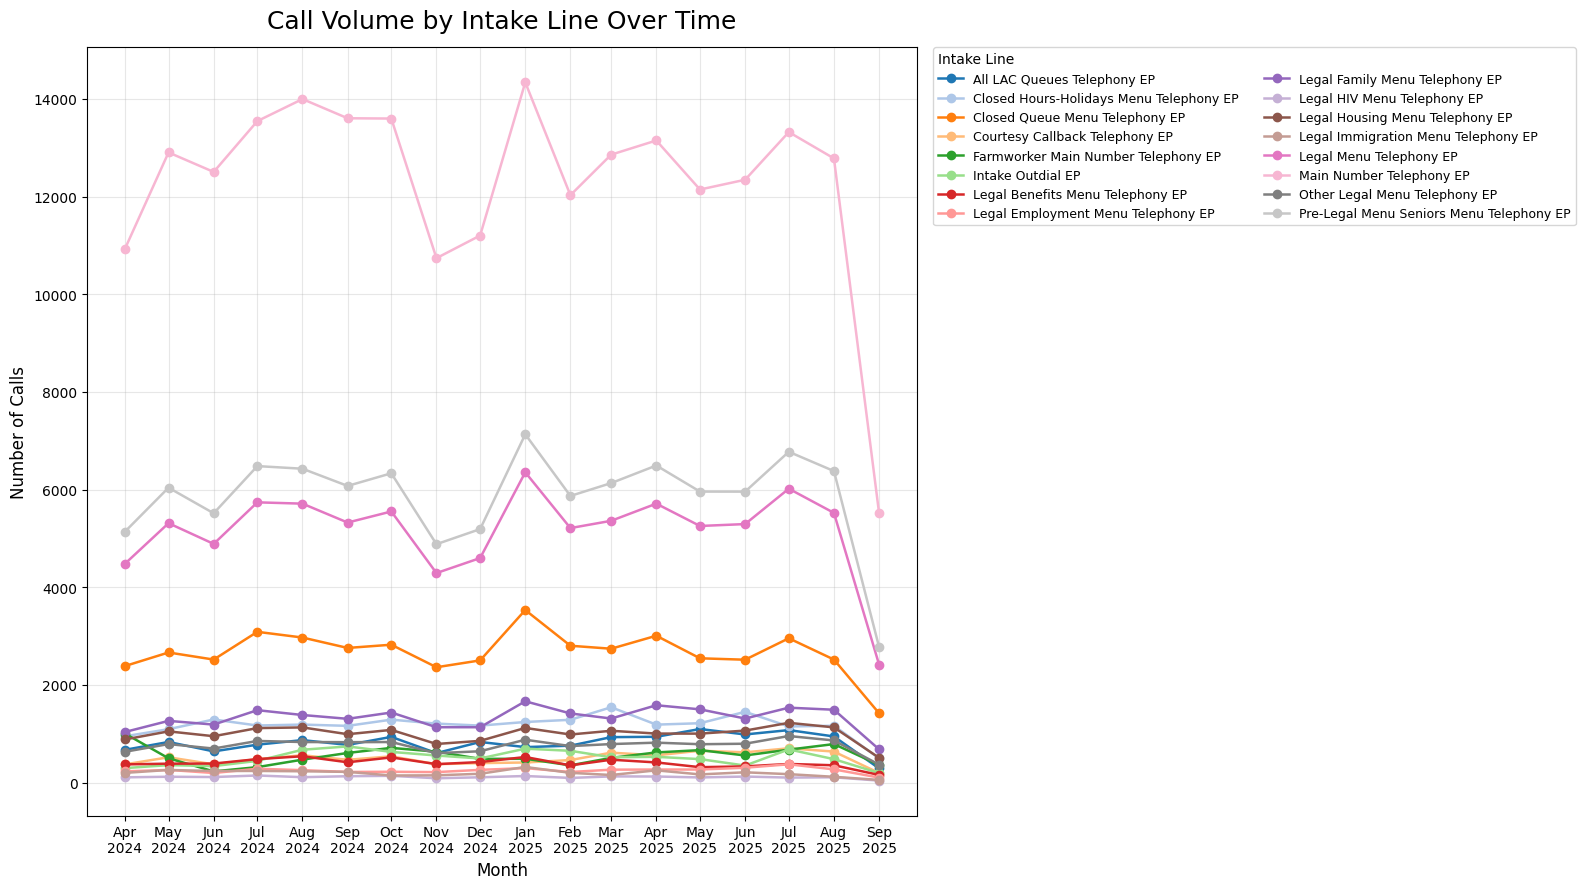

In [79]:

df_main['month'] = df_main['Activity Start Timestamp'].dt.to_period('M')

# Grouping the data to get unique call counts by month and intake line (EP Name)
line_trends = df_main.groupby(['month', 'EP Name'])['Contact Session ID'].nunique().unstack()

# Convert PeriodIndex -> Timestamp 
x = line_trends.index.to_timestamp()

# Export the grouped data for Power BI
export_3_1 = df_main.groupby(['month', 'EP Name'])['Contact Session ID'].nunique().reset_index()
export_3_1.columns = ['month', 'intake_line', 'call_count']
export_3_1['month'] = export_3_1['month'].astype(str)  

# Save as CSV
export_3_1.to_csv('q3_1_intake_line_trends.csv', index=False)
print("\nData exported to: q3_1_intake_line_trends.csv")

# Plot the data 
fig, ax = plt.subplots(figsize=(16, 9))
palette = itertools.cycle(plt.cm.tab20.colors)
for col in line_trends.columns:
    ax.plot(x, line_trends[col], marker='o', linewidth=1.8, label=col, color=next(palette))

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))  
plt.setp(ax.get_xticklabels(), rotation=0, ha='center') 


ax.set_title('Call Volume by Intake Line Over Time', fontsize=18, pad=14)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Calls', fontsize=12)
ax.grid(True, alpha=0.3)

plt.subplots_adjust(right=0.78)  
legend = ax.legend(
    title='Intake Line',
    bbox_to_anchor=(1.02, 1), loc='upper left',
    borderaxespad=0., frameon=True, fontsize=9, title_fontsize=10,
    ncol=1 if len(line_trends.columns) < 12 else 2  
)
legend._legend_box.align = "left"  

plt.tight_layout()
plt.savefig('q3_1_volume_trends_readable.png', dpi=300)
plt.show()


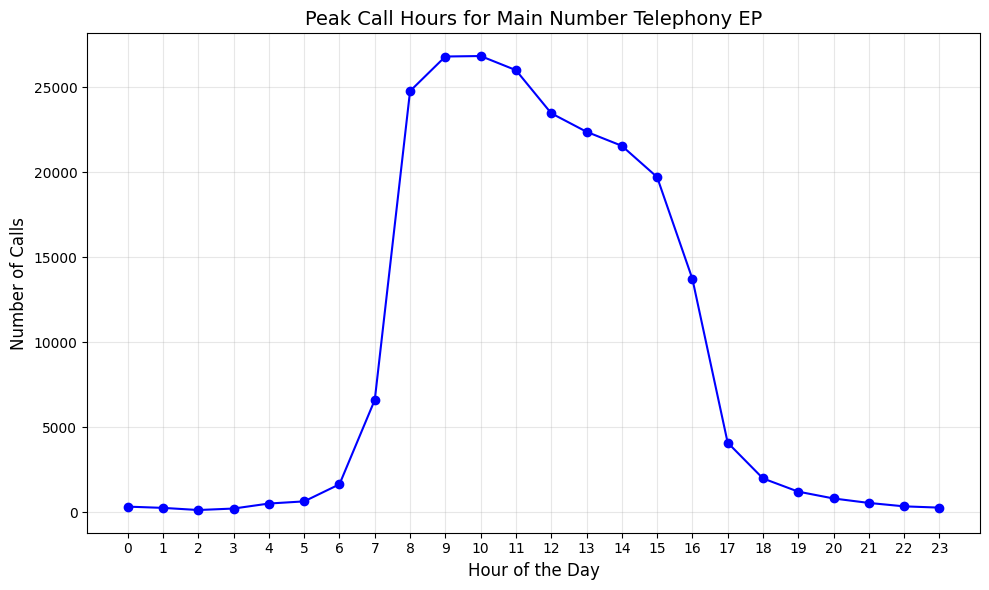

Peak call hours data saved as 'main_number_peak_hours.csv'


In [73]:
# Creating a new column 'hour' to represent the hour for time analysis
df_main['hour'] = df_main['Activity Start Timestamp'].dt.hour

# Filter the data for the "Main Number Telephony EP" intake line
main_number_calls = df_main[df_main['EP Name'] == 'Main Number Telephony EP']

# Group by hour and count the number of unique calls (Contact Session ID)
hourly_call_volume = main_number_calls.groupby('hour')['Contact Session ID'].nunique()

# Plotting the number of calls per hour
plt.figure(figsize=(10, 6))
hourly_call_volume.plot(kind='line', marker='o', color='b')
plt.title('Peak Call Hours for Main Number Telephony EP', fontsize=14)
plt.xlabel('Hour of the Day', fontsize=12)
plt.ylabel('Number of Calls', fontsize=12)
plt.xticks(range(0, 24))  
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

hourly_call_volume.to_csv('main_number_peak_hours.csv', header=True)